In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = []
path = "result_auto.txt"

with open(path, "r") as f:
    for line in f:
        parts = line.strip().split()
        
        # Isolamento delle righe contenenti i dati fisici (9 grandezze)
        if len(parts) == 9:
            try:
                p = float(parts[0])
                pitch = float(parts[1])
                perc_w = float(parts[2])
                arr_int = float(parts[3])
                arr_ext = float(parts[4])
                t_w = float(parts[5])
                t_f = float(parts[6])
                k = float(parts[7])
                err_k = float(parts[8])
               
                data.append([p, pitch, perc_w, arr_int, arr_ext, t_w, t_f, k, err_k])
            except ValueError:
                continue

df = pd.DataFrame(data, columns=[
    'pressione', 'pitch', 'perc_water', 'arricch_int', 
    'arricch_ext', 'T_water', 'T_fuel', 'k', 'err_k'
])

- Assumo che il reattore spento stia a 300 K sia in fuel che in acqua Cold Zero Power (CZP)

- definisco poi l'Hot Zero Power, cioè T_fuel = T_water ma a valori maggiori, magari 550K, cioè reattore pronto all'uso ma con ancora nessuna potenza prodotta

- infine serve il HFP = hot full power, cioè massima potenza


Per vedere una variazione:
$$\Delta\rho = \rho_2 - \rho_1 = \frac{k_2 - 1}{k_2} - \frac{k_1 - 1}{k_1} = \frac{k_2 - k_1}{k_1 \cdot k_2}$$


1. Temperature Defect (CZP $\rightarrow$ HZP) Nello stato CZP ($300\text{ K}$), il sistema è freddo. 
L'acqua ha la massima densità, offrendo la massima moderazione (spettro neutronico fortemente termico).
Scaldando il sistema allo stato HZP ($550\text{ K}$), la potenza è ancora nulla, quindi l'equilibrio termico impone $T_{fuel} = T_{water}$. 
    1) Il calo di reattività associato (Temperature Defect) è causato da due contributi: Moderator Temperature Coefficient (MTC) [Dominante]: All'aumentare della temperatura, la densità dell'acqua crolla. Questo causa due effetti: 
    - Diminuisce il potere rallentante ($\xi \Sigma_s$), indurendo lo spettro neutronico. Più neutroni vengono assorbiti nelle risonanze epitemiche dell'$^{238}\text{U}$ prima di termalizzare.
    - Aumenta il cammino libero medio neutronico, incrementando le fughe (leakage) verso i bordi del nocciolo.
    
    2) Effetto Doppler Isotermo [Minoritario]: Anche il combustibile si scalda da $300\text{ K}$ a $550\text{ K}$, causando un primo allargamento delle risonanze di assorbimento (Doppler broadening). 

2. Power Defect (HZP $\rightarrow$ HFP) Allo stato HZP, il reattore è critico e alle condizioni nominali di pressione/temperatura del fluido, ma genera $0\text{ W}$.Portando il reattore allo stato HFP (100% potenza nominale), la temperatura del moderatore resta approssimativamente costante ($T_{water} \approx 550\text{ K}$ media), ma per trasferire l'enorme calore generato per fissione nel pellet verso il fluido, si instaura un ripido gradiente termico. La temperatura media del combustibile $T_{fuel}$ schizza a valori elevati (es. $900\text{ K}$).Il calo di reattività associato (Power Defect) è dominato esclusivamente da un fenomeno: Fuel Temperature Coefficient (FTC) o Effetto Doppler Puro: L'aumento drammatico dell'agitazione termica dei nuclei di $^{238}\text{U}$ nel reticolo cristallino dell'$UO_2$ causa un allargamento (broadening) delle sezioni d'urto di cattura risonante. Sebbene l'integrale dell'area sotto la risonanza resti teoricamente costante, l'allargamento abbassa i picchi e allarga le code (riducendo il self-shielding spaziale ed energetico). Di conseguenza, aumenta drasticamente la probabilità che un neutrone venga catturato parassiticamente dall'$^{238}\text{U}$ durante il rallentamento.Il Power Defect rappresenta il feedback negativo vitale per la stabilità e la sicurezza intrinseca del reattore: all'aumentare della potenza, la fisica stessa del nocciolo "spegne" la reazione a catena. Questo valore definisce quanta reattività (es. estraendo le barre di controllo) l'operatore deve inserire per poter effettivamente far salire il reattore da $0$ al $100\%$ di potenza.


- Temperature Defect (Moderatore + Doppler base): Transizione da CZP a HZP.
$$\Delta\rho_{temp}=\frac{k_{HZP}-k_{CZP}}{k_{HZP}\cdot k_{CZP}}\cdot 10^5\quad [pcm]$$

- Power Defect (Effetto Doppler puro): Transizione da HZP a HFP.
$$\Delta\rho_{power}=\frac{k_{HFP}-k_{HZP}}{k_{HFP}\cdot k_{HZP}}\cdot 10^5\quad [pcm]$$



In [3]:
def calc_reactivity_defect(k1, std1, k2, std2):
    """Calcola il \delta\rho in pcm e propaga l'errore statistico."""
    # Delta rho = (k2 - k1) / (k1 * k2)
    delta_rho = ((k2 - k1) / (k1 * k2)) * 1e5
    
    # Propagazione errore: \sigma_\rho = \sqrt{(\sigma_1/k_1^2)^2 + (\sigma_2/k_2^2)^2}
    err_rho = np.sqrt((std1 / k1**2)**2 + (std2 / k2**2)**2) * 1e5
    return delta_rho, err_rho

# Conversione pressione
df['pressione_atm'] = np.round(df['pressione'] / 101325.0, 2)

results = []
results_2 = []
ignorancy = -200.0  # Bias dati nucleari [pcm]

# Aggiunte variabili di arricchimento al raggruppamento per distinguere i set
for (p_atm, pitch, arr_int, arr_ext), group in df.groupby(['pressione_atm', 'pitch', 'arricch_int', 'arricch_ext']):
    
    # Filtro: richiede i 3 stati esatti
    if len(group) != 3:
        continue 
    
    # Ordinamento termodinamico: Stato 1 (Cold), Stato 2 (HZP), Stato 3 (FP)
    g = group.sort_values(by=['T_water', 'T_fuel']).reset_index(drop=True)
    
    k1, std1 = g.loc[0, 'k'], g.loc[0, 'err_k']
    k2, std2 = g.loc[1, 'k'], g.loc[1, 'err_k']
    k3, std3 = g.loc[2, 'k'], g.loc[2, 'err_k']
    
    # Calcolo difetti di reattività
    rho_temp, err_temp = calc_reactivity_defect(k1, std1, k2, std2)
    rho_pow, err_pow = calc_reactivity_defect(k2, std2, k3, std3)

    print(f"Condizione: P={p_atm} atm, Pitch={pitch}, Arr_INT={arr_int}")
    print(f"Reactivity Defect (Temp): {rho_temp :.1f} ± {err_temp :.1f} pcm")
    print(f"Reactivity Defect (Power): {rho_pow :.1f} ± {err_pow :.1f} pcm \n\n")
    
    # Reattività totale e autovalore massimo k_max
    rho_tot = rho_temp + rho_pow + ignorancy
    err_tot = np.sqrt(err_temp**2 + err_pow**2)
    
    rho_max_val = rho_tot / 1e5
    k_max = 1 / (1 - rho_max_val)
    sigma_k = (err_tot / 1e5) * (k_max**2)
    
    results_2.append({
        'P [atm]': p_atm,
        'Pitch [cm]': pitch,
        'Arr_INT [%]': arr_int,
        r'$\Delta\rho$ Temp [pcm]': f"{rho_temp:.1f} ± {err_temp:.1f}",
        r'$\Delta\rho$ Pow [pcm]': f"{rho_pow:.1f} ± {err_pow:.1f}",
        r'$\Delta\rho$ Tot [pcm]': f"{rho_tot:.1f} ± {err_tot:.1f}",
        r'$k_{max}$ Final': f"{k_max:.5f} ± {sigma_k:.5f}"
    })

    results.append({
        'pressione_atm': p_atm,      
        'pitch': pitch/(2.05*np.sqrt(3)),
        'arricch_int': arr_int,
        'arricch_ext': arr_ext,
        'rho_tot': rho_tot,
        'err_tot': err_tot,
        'k_max': k_max,
        'sigma_k': sigma_k
    })

# Visualizzazione safety guard
if len(results_2) > 0:
    df_res_2 = pd.DataFrame(results_2)
    display(df_res_2)

    df_res = pd.DataFrame(results)
    df_res['pitch'] = df_res['pitch'].round(3)
else:
    print("WARNING: Nessun set ha soddisfatto la condizione di 3 stati termodinamici esatti.")

Condizione: P=1.0 atm, Pitch=3.551, Arr_INT=0.07
Reactivity Defect (Temp): -1720.0 ± 21.0 pcm
Reactivity Defect (Power): -417.7 ± 21.5 pcm 


Condizione: P=1.0 atm, Pitch=3.551, Arr_INT=1.15
Reactivity Defect (Temp): -1732.2 ± 19.6 pcm
Reactivity Defect (Power): -445.6 ± 20.7 pcm 


Condizione: P=1.0 atm, Pitch=3.551, Arr_INT=2.34
Reactivity Defect (Temp): -1765.3 ± 18.8 pcm
Reactivity Defect (Power): -426.4 ± 21.6 pcm 


Condizione: P=1.0 atm, Pitch=3.551, Arr_INT=3.58
Reactivity Defect (Temp): -1775.1 ± 21.0 pcm
Reactivity Defect (Power): -461.5 ± 21.5 pcm 


Condizione: P=1.0 atm, Pitch=3.551, Arr_INT=4.97
Reactivity Defect (Temp): -1778.4 ± 20.3 pcm
Reactivity Defect (Power): -427.4 ± 18.5 pcm 


Condizione: P=1.0 atm, Pitch=3.551, Arr_INT=6.59
Reactivity Defect (Temp): -1789.4 ± 18.8 pcm
Reactivity Defect (Power): -425.0 ± 18.5 pcm 


Condizione: P=1.0 atm, Pitch=3.551, Arr_INT=8.46
Reactivity Defect (Temp): -1788.9 ± 19.6 pcm
Reactivity Defect (Power): -442.3 ± 19.3 pcm 


Condiz

,P [atm],Pitch [cm],Arr_INT [%],$\Delta\rho$ Temp [pcm],$\Delta\rho$ Pow [pcm],$\Delta\rho$ Tot [pcm],$k_{max}$ Final
0,1.0,3.551,0.07,-1720.0 ± 21.0,-417.7 ± 21.5,-2337.7 ± 30.1,0.97716 ± 0.00029
1,1.0,3.551,1.15,-1732.2 ± 19.6,-445.6 ± 20.7,-2377.8 ± 28.5,0.97677 ± 0.00027
2,1.0,3.551,2.34,-1765.3 ± 18.8,-426.4 ± 21.6,-2391.7 ± 28.6,0.97664 ± 0.00027
3,1.0,3.551,3.58,-1775.1 ± 21.0,-461.5 ± 21.5,-2436.6 ± 30.0,0.97621 ± 0.00029
4,1.0,3.551,4.97,-1778.4 ± 20.3,-427.4 ± 18.5,-2405.8 ± 27.5,0.97651 ± 0.00026
5,1.0,3.551,6.59,-1789.4 ± 18.8,-425.0 ± 18.5,-2414.4 ± 26.4,0.97643 ± 0.00025
6,1.0,3.551,8.46,-1788.9 ± 19.6,-442.3 ± 19.3,-2431.2 ± 27.5,0.97626 ± 0.00026
7,1.0,3.551,10.47,-1806.1 ± 19.6,-427.0 ± 19.3,-2433.2 ± 27.5,0.97625 ± 0.00026
8,1.0,3.551,12.82,-1827.1 ± 19.2,-358.1 ± 22.2,-2385.2 ± 29.3,0.97670 ± 0.00028
9,1.0,3.551,15.59,-1776.0 ± 19.6,-360.4 ± 19.3,-2336.4 ± 27.5,0.97717 ± 0.00026


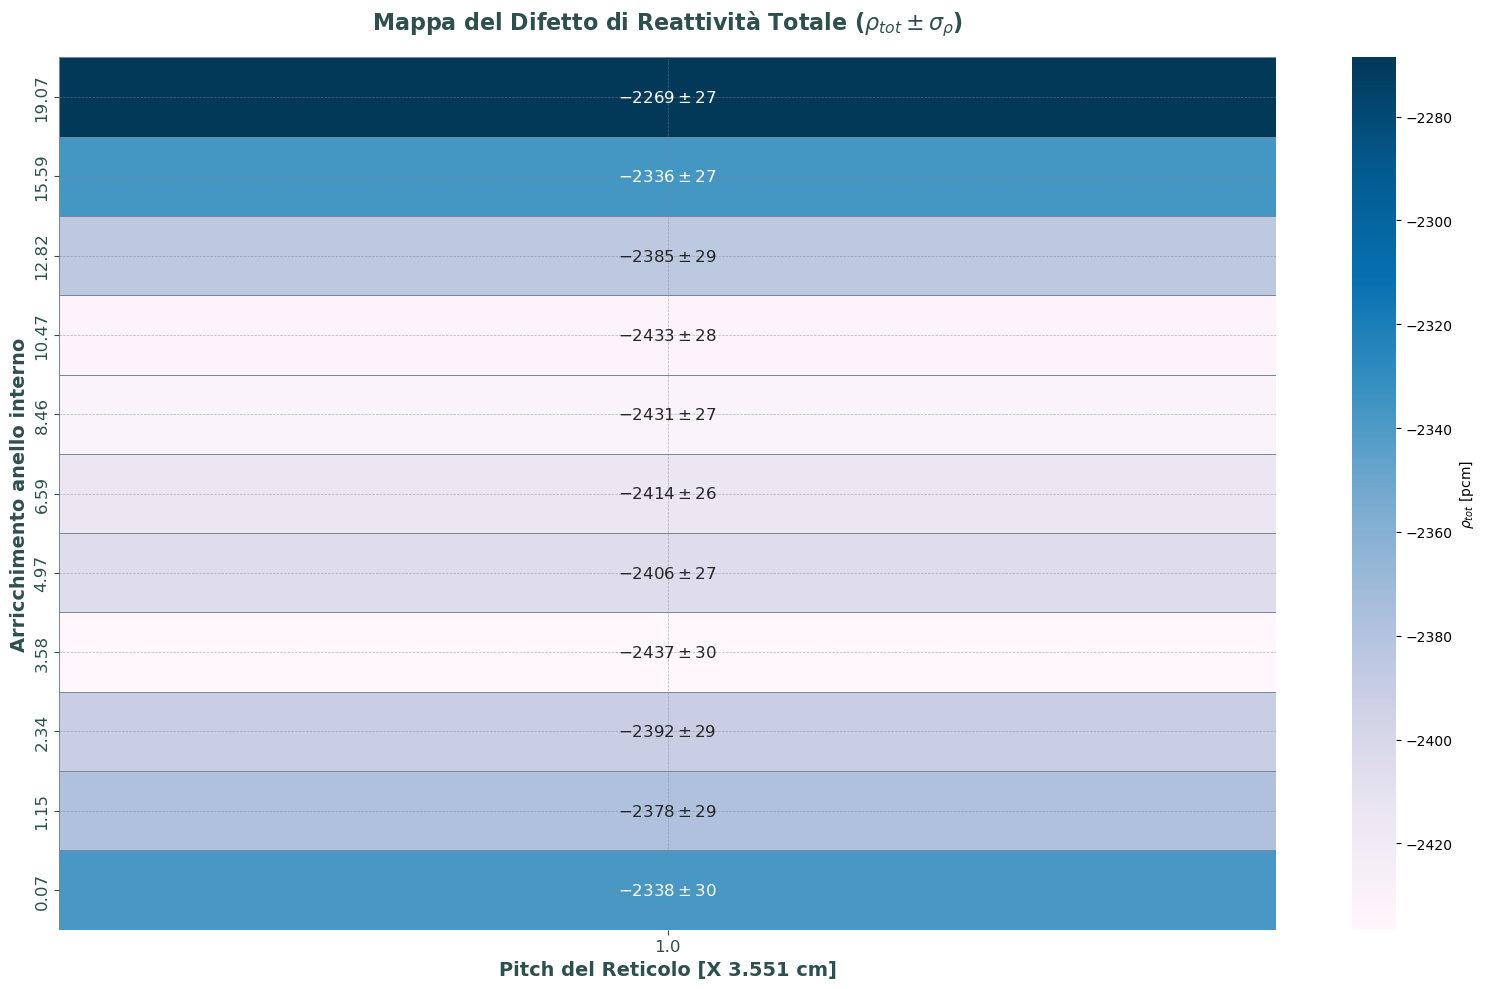

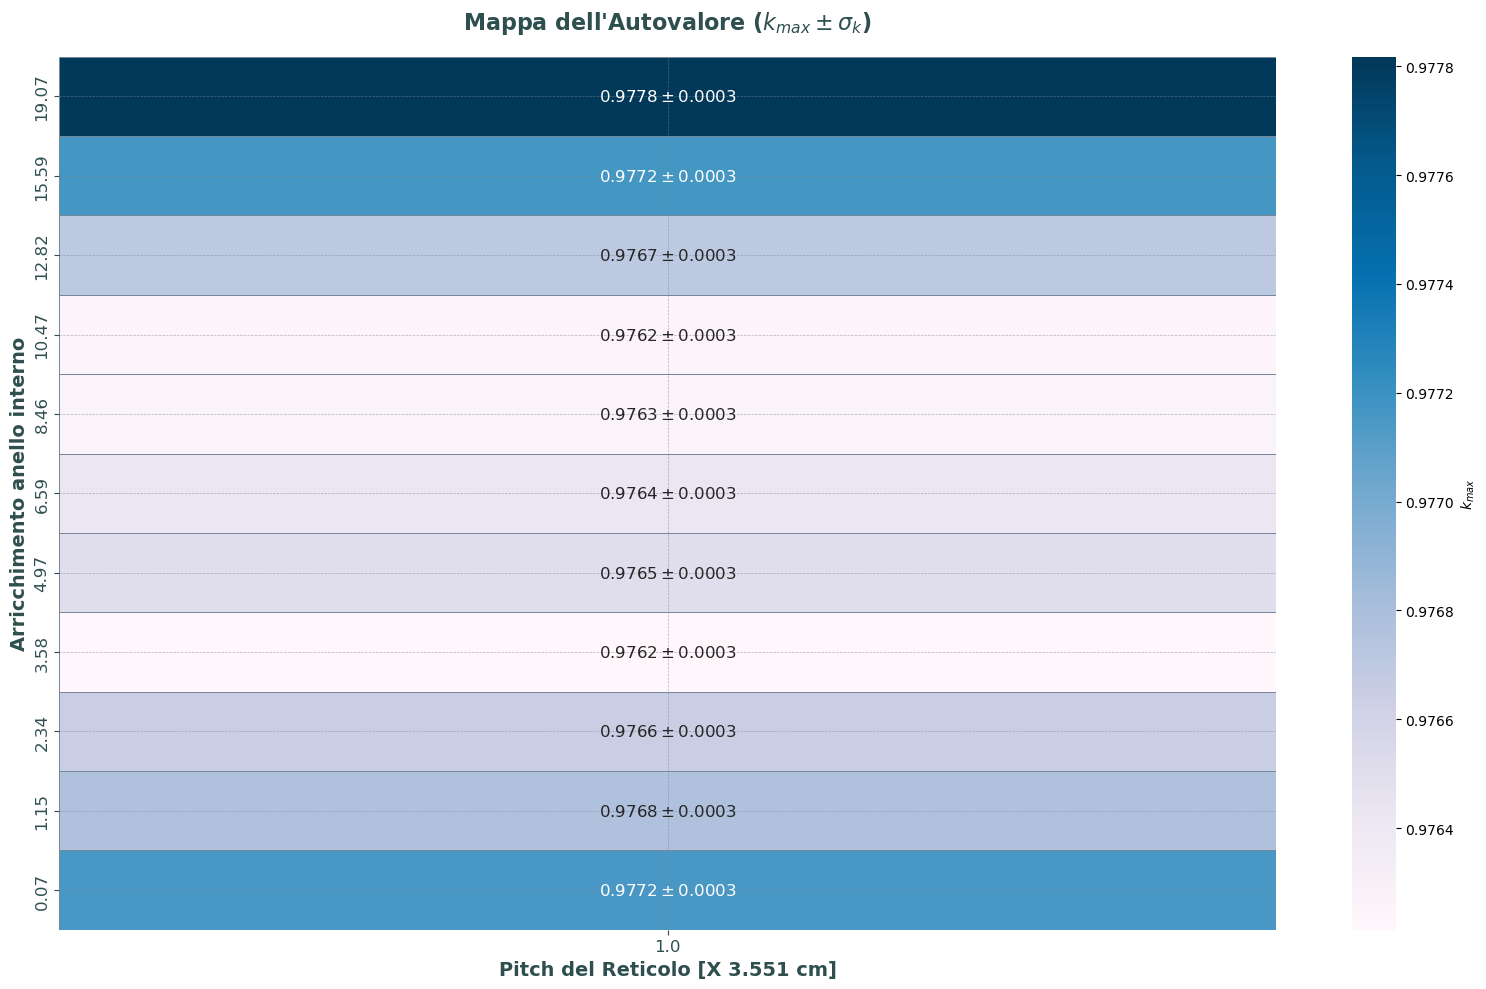

In [4]:

# matrici per Heatmap (assumendo df_res già calcolato)

pivot_rho = df_res.pivot(index='arricch_int', columns='pitch', values='rho_tot')
pivot_err_rho = df_res.pivot(index='arricch_int', columns='pitch', values='err_tot')

pivot_kmax = df_res.pivot(index='arricch_int', columns='pitch', values='k_max')
pivot_err_kmax = df_res.pivot(index='arricch_int', columns='pitch', values='sigma_k')

# Creazione delle matrici testuali di annotazione con sintassi LaTeX per il simbolo \pm
annot_rho = pd.DataFrame(
    [[f"${val:.0f} \pm {err:.0f}$" for val, err in zip(row_val, row_err)] 
     for row_val, row_err in zip(pivot_rho.values, pivot_err_rho.values)],
    index=pivot_rho.index, columns=pivot_rho.columns
)

annot_kmax = pd.DataFrame(
    [[f"${val:.4f} \pm {err:.4f}$" for val, err in zip(row_val, row_err)] 
     for row_val, row_err in zip(pivot_kmax.values, pivot_err_kmax.values)],
    index=pivot_kmax.index, columns=pivot_kmax.columns
)

lbl_props = {'fontsize': 14, 'fontweight': 'bold', 'color': '#2F4F4F'}
tit_props = {'fontsize': 16, 'fontweight': 'bold', 'color': '#2F4F4F'}
cmap_cool = "PuBu" 

def format_axes(ax):
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899', linewidth=0.5)
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899', linewidth=0.5)
    ax.tick_params(axis='x', colors='#2F4F4F', labelsize=12)
    ax.tick_params(axis='y', colors='#2F4F4F', labelsize=12)

# HEATMAP 1: Reattività Totale (rho_tot)
fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(pivot_rho, annot=annot_rho, fmt="", cmap=cmap_cool, cbar_kws={'label': r'$\rho_{tot}$ [pcm]'}, 
            ax=ax, annot_kws={"size": 12}, linewidths=0.5, linecolor='#778899')

ax.set_title(r"Mappa del Difetto di Reattività Totale ($\rho_{tot} \pm \sigma_{\rho}$)", **tit_props, pad=20)
ax.set_ylabel("Arricchimento anello interno", **lbl_props)
ax.set_xlabel("Pitch del Reticolo [X 3.551 cm]", **lbl_props)
ax.invert_yaxis()
format_axes(ax)
plt.tight_layout()
plt.show()

# HEATMAP 2: Autovalore Massimo (k_max)
fig, ax2 = plt.subplots(figsize=(16, 10))
sns.heatmap(pivot_kmax, annot=annot_kmax, fmt="", cmap=cmap_cool, cbar_kws={'label': r'$k_{max}$'}, 
            ax=ax2, annot_kws={"size": 12}, linewidths=0.5, linecolor='#778899')

ax2.set_title(r"Mappa dell'Autovalore ($k_{max} \pm \sigma_{k}$)", **tit_props, pad=20)
ax2.set_ylabel("Arricchimento anello interno", **lbl_props)
ax2.set_xlabel("Pitch del Reticolo [X 3.551 cm]", **lbl_props)
ax2.invert_yaxis()
format_axes(ax2)
plt.tight_layout()
plt.show()

In [5]:
# Salvataggio di tutti i k_max, pitch, pressione e delta rho su file
filename = "k_max.txt"

with open(filename, "w") as f:
    # Intestazione del file
    f.write(f"{'Pressione [atm]':<18} | {'Pitch':<10} | {'k_max +/- sigma_k':<22} | {'Delta_rho +/- err_rho [pcm]'}\n")
    f.write("-" * 85 + "\n")
    
    # Iterazione su tutte le righe del DataFrame
    for _, row in df_res.iterrows():
        p_atm = row['pressione_atm']
        pitch = row['pitch']
        k_max = row['k_max']
        sig_k = row['sigma_k']
        rho = row['rho_tot']
        err_rho = row['err_tot']
        
        # Scrittura formattata
        f.write(f"{p_atm:<18.2f} | {pitch:<10.3f} | {k_max:.5f} +/- {sig_k:.5f} | {rho:.1f} +/- {err_rho:.1f}\n")

print(f"Dati salvati con successo in {filename}")

Dati salvati con successo in k_max.txt


=== VALUTAZIONE COMPATIBILITÀ ===
Valore di riferimento: 0.97547 +/- 0.00020
Media Pesata calcolata: 0.97672 +/- 0.00008
Compatibilità tra le due rette: 5.80 sigma

Pitch      | k_max      | err_k      | Sigma Ref  | Sigma Media
-----------------------------------------------------------------
0.0700     | 0.97716    | 0.00029    | 4.82       | 1.46      
1.1500     | 0.97677    | 0.00027    | 3.86       | 0.19      
2.3400     | 0.97664    | 0.00027    | 3.46       | 0.28      
3.5800     | 0.97621    | 0.00029    | 2.13       | 1.71      
4.9700     | 0.97651    | 0.00026    | 3.15       | 0.78      
6.5900     | 0.97643    | 0.00025    | 2.97       | 1.12      
8.4600     | 0.97626    | 0.00026    | 2.41       | 1.67      
10.4700    | 0.97625    | 0.00026    | 2.35       | 1.73      
12.8200    | 0.97670    | 0.00028    | 3.59       | 0.06      
15.5900    | 0.97717    | 0.00026    | 5.15       | 1.63      
19.0700    | 0.97782    | 0.00026    | 7.17       | 4.04      


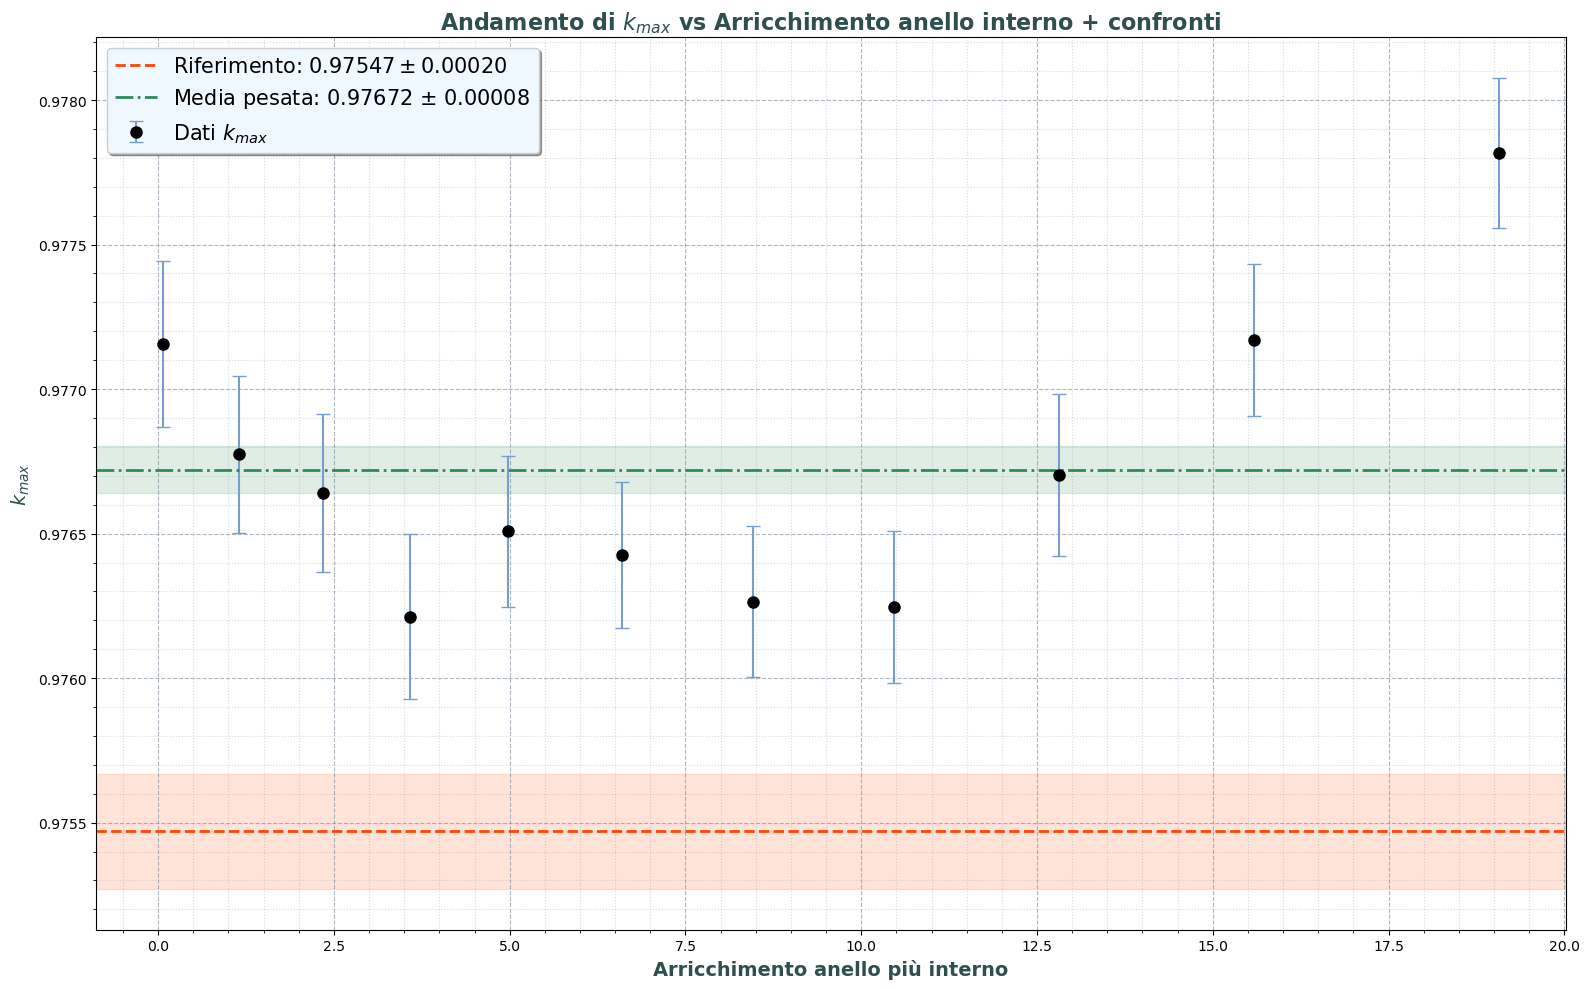

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# --- 1. Estrazione dati ---
x = df_res['arricch_int'].values
y_k = df_res['k_max'].values
err_k = df_res['sigma_k'].values

# --- 2. Dati della retta di riferimento ---
y_ref = 0.97547
err_ref = 0.0002

# --- 3. Calcolo Media Pesata ---
pesi = 1.0 / (err_k**2)
y_wa = np.sum(y_k * pesi) / np.sum(pesi)
err_wa = np.sqrt(1.0 / np.sum(pesi))

# --- 4. Calcolo Compatibilità (in sigma) ---
# La formula utilizzata è la distanza pesata con somma in quadratura delle incertezze
comp_ref = np.abs(y_k - y_ref) / np.sqrt(err_k**2 + err_ref**2)
comp_wa = np.abs(y_k - y_wa) / np.sqrt(err_k**2 + err_wa**2)
comp_lines = np.abs(y_ref - y_wa) / np.sqrt(err_ref**2 + err_wa**2)

# --- 5. Stampa a schermo delle valutazioni ---
print("=== VALUTAZIONE COMPATIBILITÀ ===")
print(f"Valore di riferimento: {y_ref:.5f} +/- {err_ref:.5f}")
print(f"Media Pesata calcolata: {y_wa:.5f} +/- {err_wa:.5f}")
print(f"Compatibilità tra le due rette: {comp_lines:.2f} sigma\n")

print(f"{'Pitch':<10} | {'k_max':<10} | {'err_k':<10} | {'Sigma Ref':<10} | {'Sigma Media':<10}")
print("-" * 65)
for i in range(len(x)):
    print(f"{x[i]:<10.4f} | {y_k[i]:<10.5f} | {err_k[i]:<10.5f} | {comp_ref[i]:<10.2f} | {comp_wa[i]:<10.2f}")

# --- 6. Proprietà Grafiche (stile unificato) ---
lbl_props = {'fontsize': 14, 'fontweight': 'bold', 'color': '#2F4F4F'}
tit_props = {'fontsize': 16, 'fontweight': 'bold', 'color': '#2F4F4F'}
legend_props = {'loc': 'best', 'frameon': True, 'shadow': True, 'fontsize': 15, 'facecolor': '#F0F8FF'}

# Generazione del Plot
fig, ax = plt.subplots(figsize=(16, 10))

# Plot punti sperimentali con barre d'errore
ax.errorbar(x, y_k, yerr=err_k, fmt='o', color='#000000', 
            ecolor='#789DD1', capsize=5, markersize=8, label='Dati $k_{max}$')

# Plot Retta di Riferimento e Fascia (utilizzo axhspan per coprire tutto l'asse X)
ax.axhline(y_ref, color='#FF4500', linestyle='--', linewidth=2, label='Riferimento: $0.97547 \pm 0.00020$')
ax.axhspan(y_ref - err_ref, y_ref + err_ref, color='#FF4500', alpha=0.15)

# Plot Media Pesata e Fascia
ax.axhline(y_wa, color='#2E8B57', linestyle='-.', linewidth=2, label=f'Media pesata: {y_wa:.5f} $\pm$ {err_wa:.5f}')
ax.axhspan(y_wa - err_wa, y_wa + err_wa, color='#2E8B57', alpha=0.15)

# Formattazione assi e titolo
ax.set_xlabel('Arricchimento anello più interno', **lbl_props)
ax.set_ylabel('$k_{max}$', **lbl_props)
ax.set_title('Andamento di $k_{max}$ vs Arricchimento anello interno + confronti', **tit_props)

# Controllo densità dei tick minori
ax.xaxis.set_minor_locator(AutoMinorLocator(20))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.minorticks_on()

# Setup della griglia e legenda
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax.legend(**legend_props)

plt.tight_layout()
plt.show()